Using device: cuda
Epoch 50, Loss: -2.7232601642608643
Epoch 100, Loss: -2.3536605834960938
final best loss: -3.062838554382324


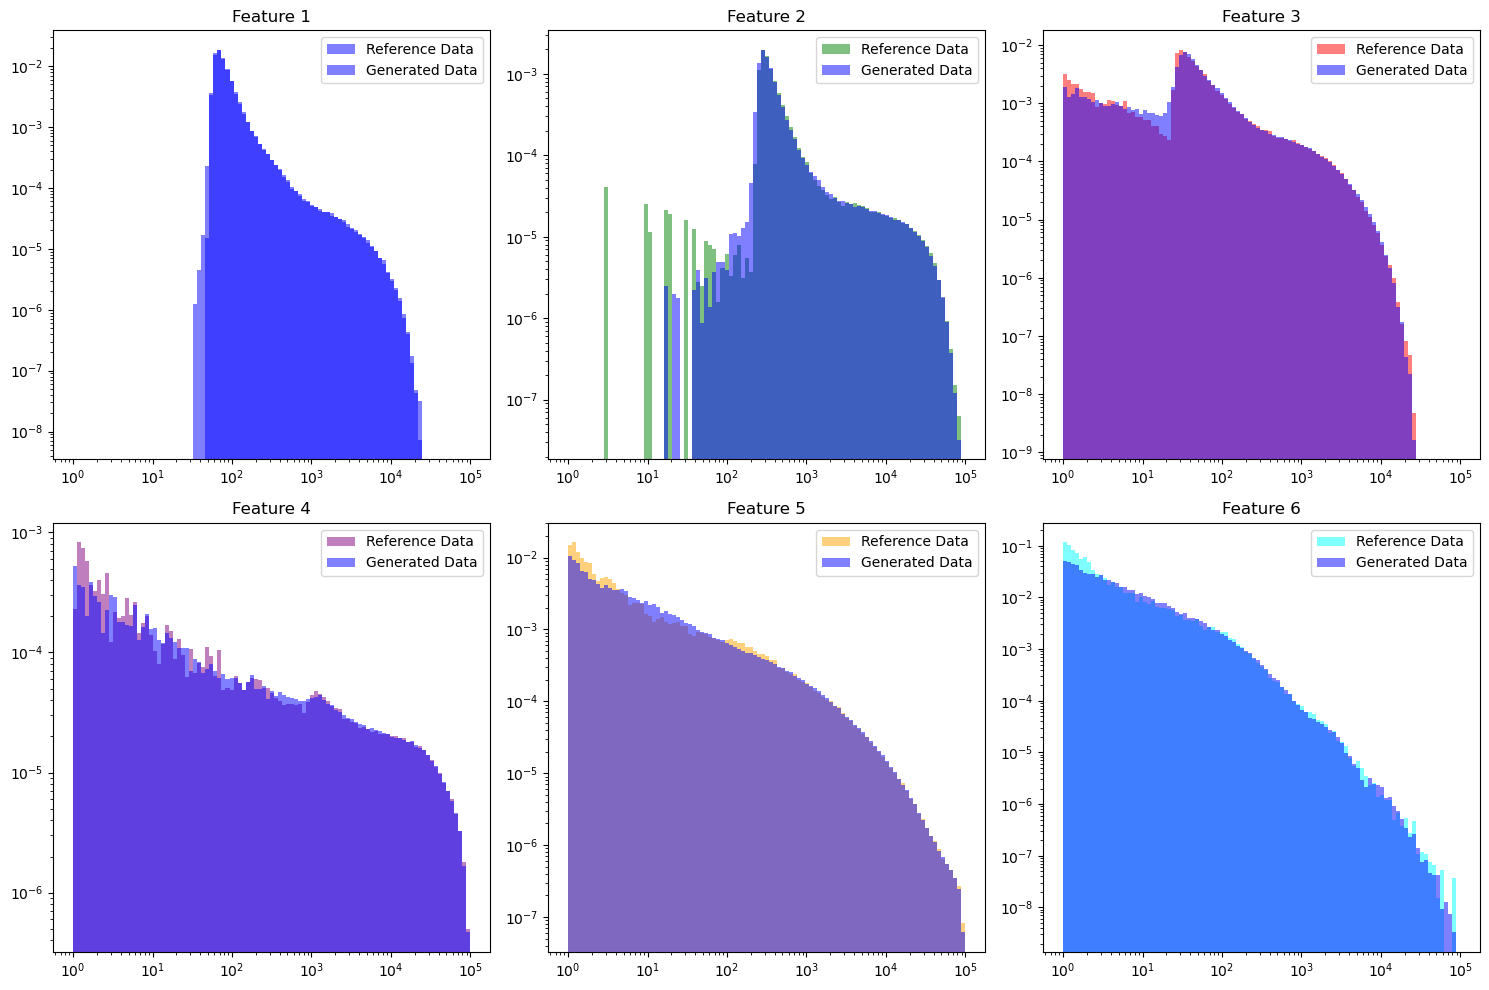

Total time taken until histograms: 0h 35m 17.51s


In [4]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.coupling import PiecewiseRationalQuadraticCouplingTransform  
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim


start_time = time.time() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)

def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

# Load and preprocess data
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

data = np.hstack((energy.reshape(-1, 1), E_layers))
data[np.isinf(data)] = np.nan
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std


data_mean_reg = data_mean
data_std_reg = data_std
data_max_reg = data_max

context_feature = data_tensor[:, 0].unsqueeze(1)
input_features = data_tensor[:, 1:]

# Define the Flow model
num_layers = 10  
num_features = input_features.shape[1]
base_distribution = StandardNormal(shape=[num_features])

transforms = []

# Create alternating masks for coupling layers
masks = [torch.arange(num_features) % 2 for _ in range(num_layers)]
masks = [mask if i%2==0 else 1-mask for i,mask in enumerate(masks)]

# Define a custom MLP for the transformation network
class CouplingMLP(nn.Module):
    def __init__(self, in_features, out_features, context_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features + context_features, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, out_features)
        )
        self.hidden_features = 64

    def forward(self, identity_split, context):
        # Concatenate inputs with context
        inputs = torch.cat([identity_split, context], dim=-1)
        return self.net(inputs)

# Modify Flow model to use the custom MLP
for i in range(num_layers):
   # transforms.append(ReversePermutation(features=num_features))
    transforms.append(PiecewiseRationalQuadraticCouplingTransform(
        mask=masks[i],
        transform_net_create_fn=lambda in_features, out_features: CouplingMLP(in_features, out_features, context_features=1),
        num_bins=10,
        tails="linear",
        tail_bound=15.0
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

# Training the Flow
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 100
batch_size = 256
best_loss = float('inf')

for epoch in range(num_epochs):
    idx = torch.randperm(len(data_tensor))
    data_tensor = data_tensor[idx]
    context_feature = data_tensor[:, 0].unsqueeze(1)
    input_features = data_tensor[:, 1:]

    for i in range(0, len(input_features), batch_size):
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]
        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()
        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            best_loss = min(best_loss, loss.item())
        else:
            print("skipping")
        #print(f"batch {i + 1}, Loss: {loss.item()}")
            
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")
print(f"final best loss: {best_loss}")
# Generate samples
n_samples = 200000
batch_size = 1000
all_samples = []

Einc_gen = torch.rand((n_samples, 1)).to(device) * 99 + 1
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch_context = Einc_gen[i:i + batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()
        all_samples.append(samples_batch)

samples = torch.cat(all_samples, dim=0)
samples = samples * data_std[1:].cpu() + data_mean[1:].cpu()
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()

# Plot Histograms
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(data.shape[1] - 1):
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1], bins=bins, alpha=0.5, label="Reference Data", color=colors[i % len(colors)], density=True, log=True
    )
    axs[i].hist(samples[:, i], bins=bin_edges, alpha=0.5, label="Generated Data", color='blue', density=True, log=True)
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")

for j in range(len(axs)):
    if j >= data.shape[1] - 1:
        axs[j].axis('off')

plt.tight_layout()
plt.show()
end1_time = time.time()
elapsed_time = end1_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total time taken until histograms: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

In [1]:
print(masks)
print(flow)
total_parameters = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(f"flow has {total_parameters} trainable parameters")

n_samples = 200000
batch_size = 1000
all_samples = []

Einc_gen = torch.rand((n_samples, 1)).to(device) * 99 + 1
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        batch_context = Einc_gen[i:i + batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()
        all_samples.append(samples_batch)

samples = torch.cat(all_samples, dim=0)


NameError: name 'masks' is not defined

In [ ]:
for i in range(6):
    _,bins, _ = plt.hist(samples.squeeze().numpy()[:,i],bins=200,density=True)
    plt.hist(input_features[:,i].detach().cpu().numpy(), bins=bins,density=True)
    plt.show()

In [5]:
#CLASSIFIER
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

ALPHA = 1e-6

import numpy as np

def logit(x):
    return np.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = np.clip(ALPHA + (1. - 2. * ALPHA) * x, 1e-6, 1 - 1e-6)
    return logit(local_x)


real_data = data_tensor.cpu().numpy()
Einc_gen_numpy = Einc_gen.cpu().numpy().reshape(-1, 1) 
samples_with_einc = np.hstack((Einc_gen_numpy, samples))  
generated_data = samples_with_einc

print(type(real_data))
print(type(generated_data))

# Compute max, mean, std based on **combined** dataset
combined = np.vstack((real_data, generated_data))

data_max = combined.max(axis=0)
data_mean = combined.mean(axis=0)
data_std = combined.std(axis=0)

# Apply same transformations to both datasets
real_data = real_data / data_max
generated_data = generated_data / data_max

real_data = logit_trafo(real_data)
generated_data = logit_trafo(generated_data)

real_data = (real_data - data_mean) / data_std
generated_data = (generated_data - data_mean) / data_std

#changes end here

# Create labels
smallest_size = min(len(real_data), len(generated_data))

# Randomly select smallest_size indices
real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

# Select only those samples
real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

# combining of real and KDE gen data
#combined_data = np.vstack((real_data[:, 1:], generated_data))
combined_data = np.vstack((real_data, generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42)

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), negative_slope=0.01)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.01)
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.9f} Acc: {:.9f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc  > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:9f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []
    all_preds_auc = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            preds_auc = outputs
            all_preds_auc.append(preds_auc.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds_auc = np.concatenate(all_preds_auc)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds_auc)
    print('Accuracy: {:.9f}, AUC (area under roc curve): {:.9f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)
}

# Model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)

end_time = time.time()
elapsed_time = end_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total time taken: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Final real data shape: (70000, 7)
Final gen shape: (70000, 7)
Epoch number 0/24
----------
train Loss: 0.694425342 Acc: 0.499625000
val Loss: 0.693320925 Acc: 0.496607143
Epoch number 1/24
----------
train Loss: 0.693289464 Acc: 0.500026786
val Loss: 0.693169156 Acc: 0.498607143
Epoch number 2/24
----------
train Loss: 0.693267655 Acc: 0.499258929
val Loss: 0.693129457 Acc: 0.503428571
Epoch number 3/24
----------
train Loss: 0.693272500 Acc: 0.499687500
val Loss: 0.693152580 Acc: 0.497321429
Epoch number 4/24
----------
train Loss: 0.693247545 Acc: 0.498794643
val Loss: 0.693316140 Acc: 0.496464286
Epoch number 5/24
----------
train Loss: 0.693255296 Acc: 0.501294643
val Loss: 0.693129270 Acc: 0.503392857
Epoch number 6/24
----------
train Loss: 0.693211843 Acc: 0.498982143
val Loss: 0.693345854 Acc: 0.496607143
Epoch number 7/24
----------
train Loss: 0.693254676 Acc: 0.499446429
val Loss: 0.693145666 Acc: 0.499750000
Epoch number 8/24


tensor(99.9993, device='cuda:0')
E_inc=10 GeV: mean error = 0.39, std = 2.29
  Bin count of true energy (10 GeV): 35922 (35.92% of all results)
  Full width at half maximum (FWHM): 3.58 GeV
E_inc=20 GeV: mean error = 0.55, std = 3.43
  Bin count of true energy (20 GeV): 27101 (27.10% of all results)
  Full width at half maximum (FWHM): 5.37 GeV
E_inc=30 GeV: mean error = 0.87, std = 4.33
  Bin count of true energy (30 GeV): 21384 (21.38% of all results)
  Full width at half maximum (FWHM): 5.37 GeV
E_inc=40 GeV: mean error = 1.11, std = 5.28
  Bin count of true energy (40 GeV): 17334 (17.33% of all results)
  Full width at half maximum (FWHM): 7.16 GeV
E_inc=50 GeV: mean error = 1.54, std = 6.44
  Bin count of true energy (50 GeV): 15072 (15.07% of all results)
  Full width at half maximum (FWHM): 10.74 GeV
E_inc=60 GeV: mean error = 2.11, std = 7.86
  Bin count of true energy (60 GeV): 13291 (13.29% of all results)
  Full width at half maximum (FWHM): 10.74 GeV
E_inc=70 GeV: mean erro

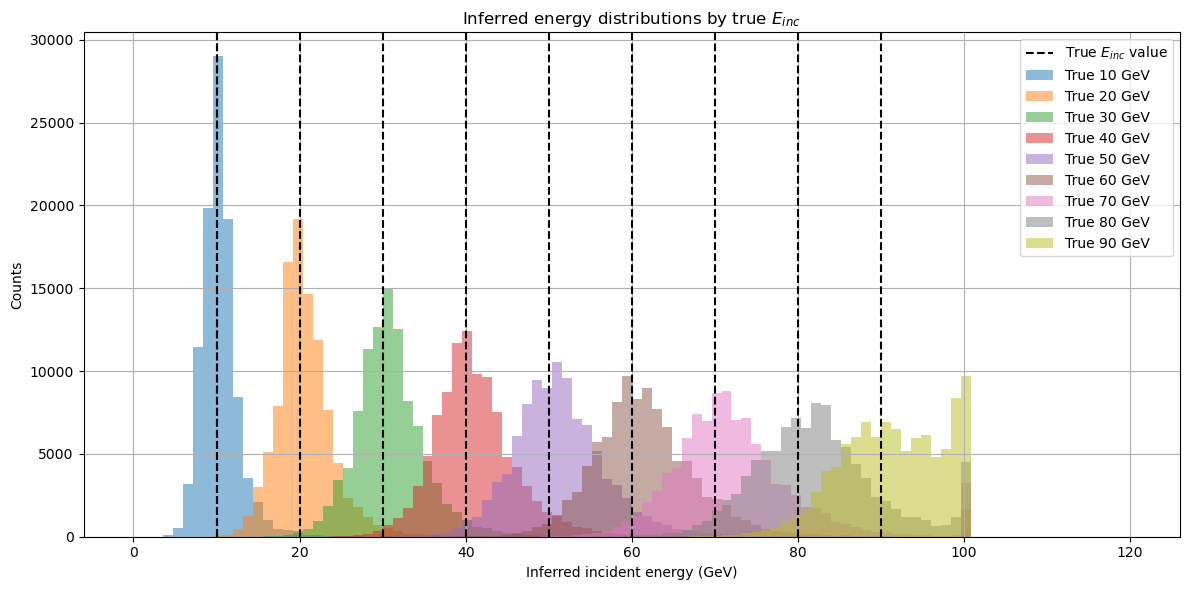

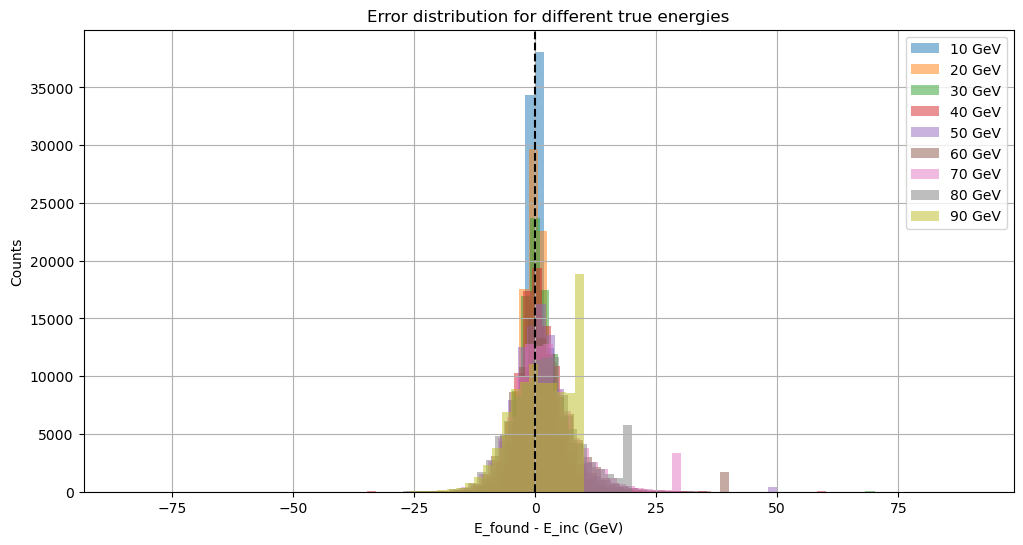

In [6]:
import os
energy_values = list(range(10, 91, 10)) 
eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
errors_by_energy = {}
print(data_max_reg[0])

def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

#LOAD AND PREPROCESS TEST DATA
def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    valid_mask = ~np.isnan(data).any(axis=1)
    data = data[valid_mask]

    tensor_data = torch.tensor(data, dtype=torch.float32).to(device)
    #preprocessing
    tensor_data = tensor_data / data_max_reg  
    tensor_data = logit_trafo_reg(tensor_data)  
    tensor_data = (tensor_data - data_mean_reg) / data_std_reg 

    return tensor_data[:, 1:]  #return only layers (context is inferred)

#ENERGY INFERENCE
def infer_incident_energy(flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg, num_scan_points=1000):
    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]
    E_candidates = torch.linspace(1, 180, num_scan_points, device=device).view(-1, 1)


    E_candidates_norm = E_candidates / data_max_reg[0]
    #E_candidates_norm = E_candidates / 120.0
    E_candidates_logit = logit_trafo_reg(E_candidates_norm)
    E_candidates_std = (E_candidates_logit - data_mean_reg[0]) / data_std_reg[0]

    #prep context
    E_context = E_candidates_std.view(1, -1, 1).repeat(n_samples, 1, 1)  # [n_samples, num_scan_points, 1]
    inputs = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)     # [n_samples, num_scan_points, features]


    flat_inputs = inputs.view(-1, inputs.shape[-1])      # [n_samples *num_scan_points, features]
    flat_context = E_context.view(-1, 1)                 # [n_samples *num_scan_points, 1]

    batch_size = 1000  
    log_probs_list = []
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            inputs_batch = flat_inputs[i:i + batch_size]
            context_batch = flat_context[i:i + batch_size]
            log_probs_batch = flow.log_prob(inputs_batch, context=context_batch)
            log_probs_list.append(log_probs_batch)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
   
    #select max logprob index for each sample 
    max_indices = log_probs.argmax(dim=1)
    inferred_E = E_candidates[max_indices].cpu().numpy()

    #return log_probs
    return inferred_E

#training values
data_mean_reg = data_mean_reg.to(device)
data_std_reg = data_std_reg.to(device)    
data_max_reg = data_max_reg.to(device)   
flow =flow.to(device)   



#test_layers_tensor = load_and_preprocess_test_file(test_file_path, data_mean_reg, data_std_reg, data_max_reg)
#inferred_energies = infer_incident_energy(flow, test_layers_tensor, data_mean_reg, data_std_reg, data_max_reg)
#print(inferred_energies)
#inserted starts
# Define the folder containing the evaluation files (e.g., piplus_10GeV.hdf5, ...)
eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))  # [10, 20, ..., 100]

errors_by_energy = {}

for E_true in energy_values:
    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')

    # Load and preprocess test samples
    layer_tensor = load_and_preprocess_test_file(file_path, data_mean_reg, data_std_reg, data_max_reg)

    # Infer E_inc for each sample
    inferred = infer_incident_energy(flow, layer_tensor, data_mean_reg, data_std_reg, data_max_reg)

    # Compute error E_found - E_true
   # clipped = np.clip(inferred, 1, 180)  # or 1–200 depending on your histogram range
    error = inferred - E_true
    errors_by_energy[E_true] = error

    print(f"E_inc={E_true} GeV: mean error = {np.mean(error):.2f}, std = {np.std(error):.2f}")
    
    #added
        # Histogram bins
    bins = 100
    #clipped = np.clip(inferred, 1, 160)
    counts, bin_edges = np.histogram(inferred, bins=bins, range=(1, 180))

    # Bestimme das Bin, in das der wahre Wert fällt
    bin_idx = np.digitize(E_true, bin_edges) - 1
    if bin_idx < 0: bin_idx = 0
    if bin_idx >= len(counts): bin_idx = len(counts) - 1

    # Anzahl der Treffer im Bin des true values
    true_bin_count = counts[bin_idx]
    total_counts = counts.sum()
    ratio_true_bin = true_bin_count / total_counts if total_counts > 0 else 0

    print(f"  Bin count of true energy ({E_true} GeV): {true_bin_count} ({ratio_true_bin:.2%} of all results)")

    # FWHM berechnen
    max_count = counts.max()
    half_max = max_count / 2

    # Indizes der Bins mit count >= halbem Maximum
    above_half_max = np.where(counts >= half_max)[0]
    if len(above_half_max) > 0:
        fwhm_start = bin_edges[above_half_max[0]]
        fwhm_end = bin_edges[above_half_max[-1] + 1]
        fwhm = fwhm_end - fwhm_start
    else:
        fwhm = 0

    print(f"  Full width at half maximum (FWHM): {fwhm:.2f} GeV")

    
plt.figure(figsize=(12, 6))
first_E_true = energy_values[0]
dashed_line = plt.axvline(first_E_true, color='black', linestyle='--', label='True $E_{inc}$ value')

# Plot histograms and collect handles
hist_handles = []
hist_labels = []

# Flag to label only one vertical line in legend
dashed_label_done = False

for E_true, error in errors_by_energy.items():
    inferred = error + E_true
    hist = plt.hist(inferred, bins=100, range=(0, 120), alpha=0.5, label=f'True {E_true} GeV')
    hist_handles.append(hist[2])  # bar container
    hist_labels.append(f'True {E_true} GeV')

    # Plot vertical line for each E_true, but label only once
    if not dashed_label_done:
        dashed_line = plt.axvline(E_true, color='black', linestyle='--', label='True $E_{inc}$ value')
        dashed_label_done = True
    else:
        plt.axvline(E_true, color='black', linestyle='--')

# Show legend with vertical line first
plt.legend(handles=[dashed_line] + hist_handles, labels=['True $E_{inc}$ value'] + hist_labels, loc='best')


plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$")
#plt.legend(labels=line_labels + [f'True {E_true} GeV' for E_true in energy_values], loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()
# Optional: plot error histogram for all E_inc
plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f'{E_true} GeV')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("E_found - E_inc (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Error distribution for different true energies")
plt.grid(True)
plt.show()
